In [45]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor # For regression task
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score,precision_score,f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("Diamond Price prediction.csv")

In [3]:
data.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
data.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
data.drop(columns="Unnamed: 0",inplace=True)

In [6]:
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [7]:
data['clarity'].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])


In [9]:
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,2,0,2,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,1,0,2,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,4,0,2,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,3,4,3,61.0,58.0,2757,6.15,6.12,3.74


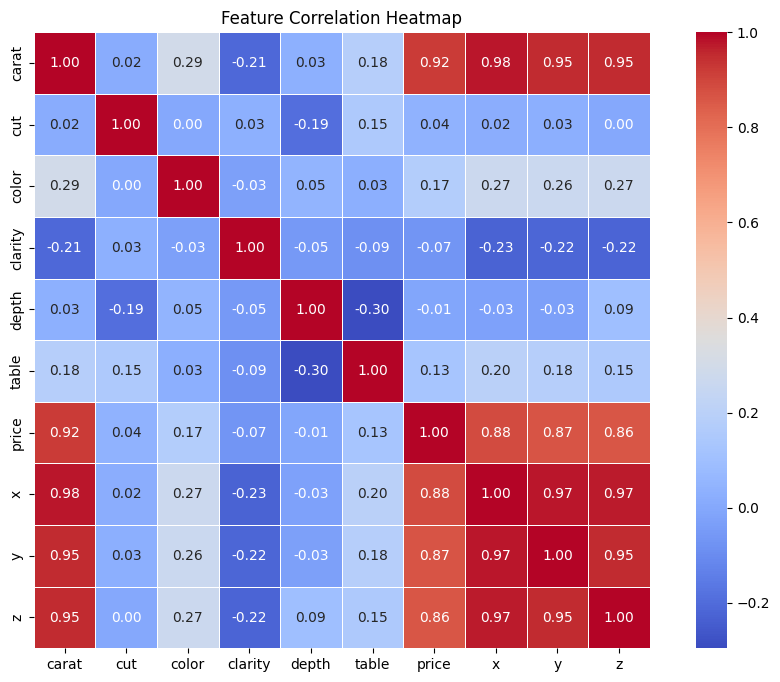

In [10]:
corr_matrix = data.corr()
plt.figure(figsize=(12, 8))  # Optional: increase figure size
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


X,y,z are having high correlation so they are needed to be removed

In [11]:


data.drop(columns="y",inplace=True)

In [12]:
data.drop(columns="x",inplace=True)

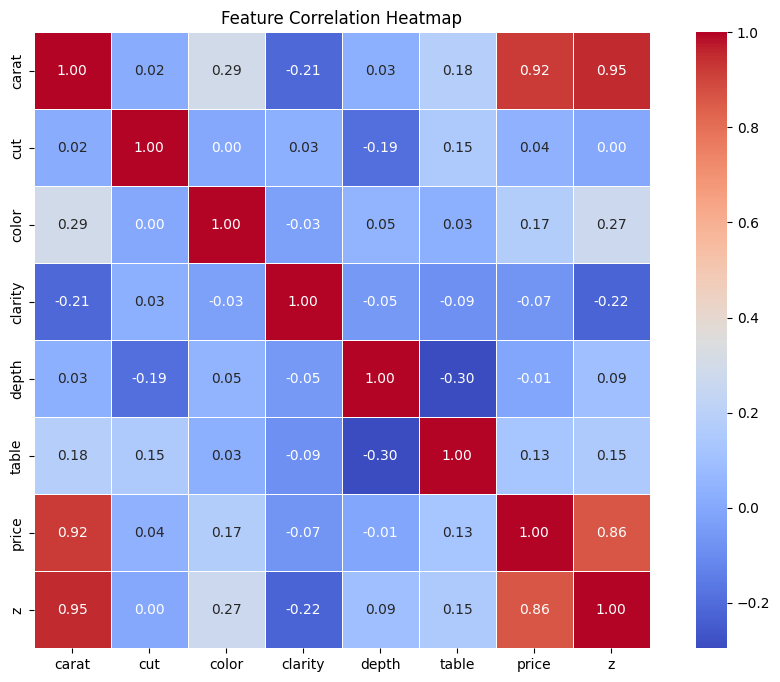

In [13]:
corr_matrix = data.corr()
plt.figure(figsize=(12, 8))  # Optional: increase figure size
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Now there is less correlations than before

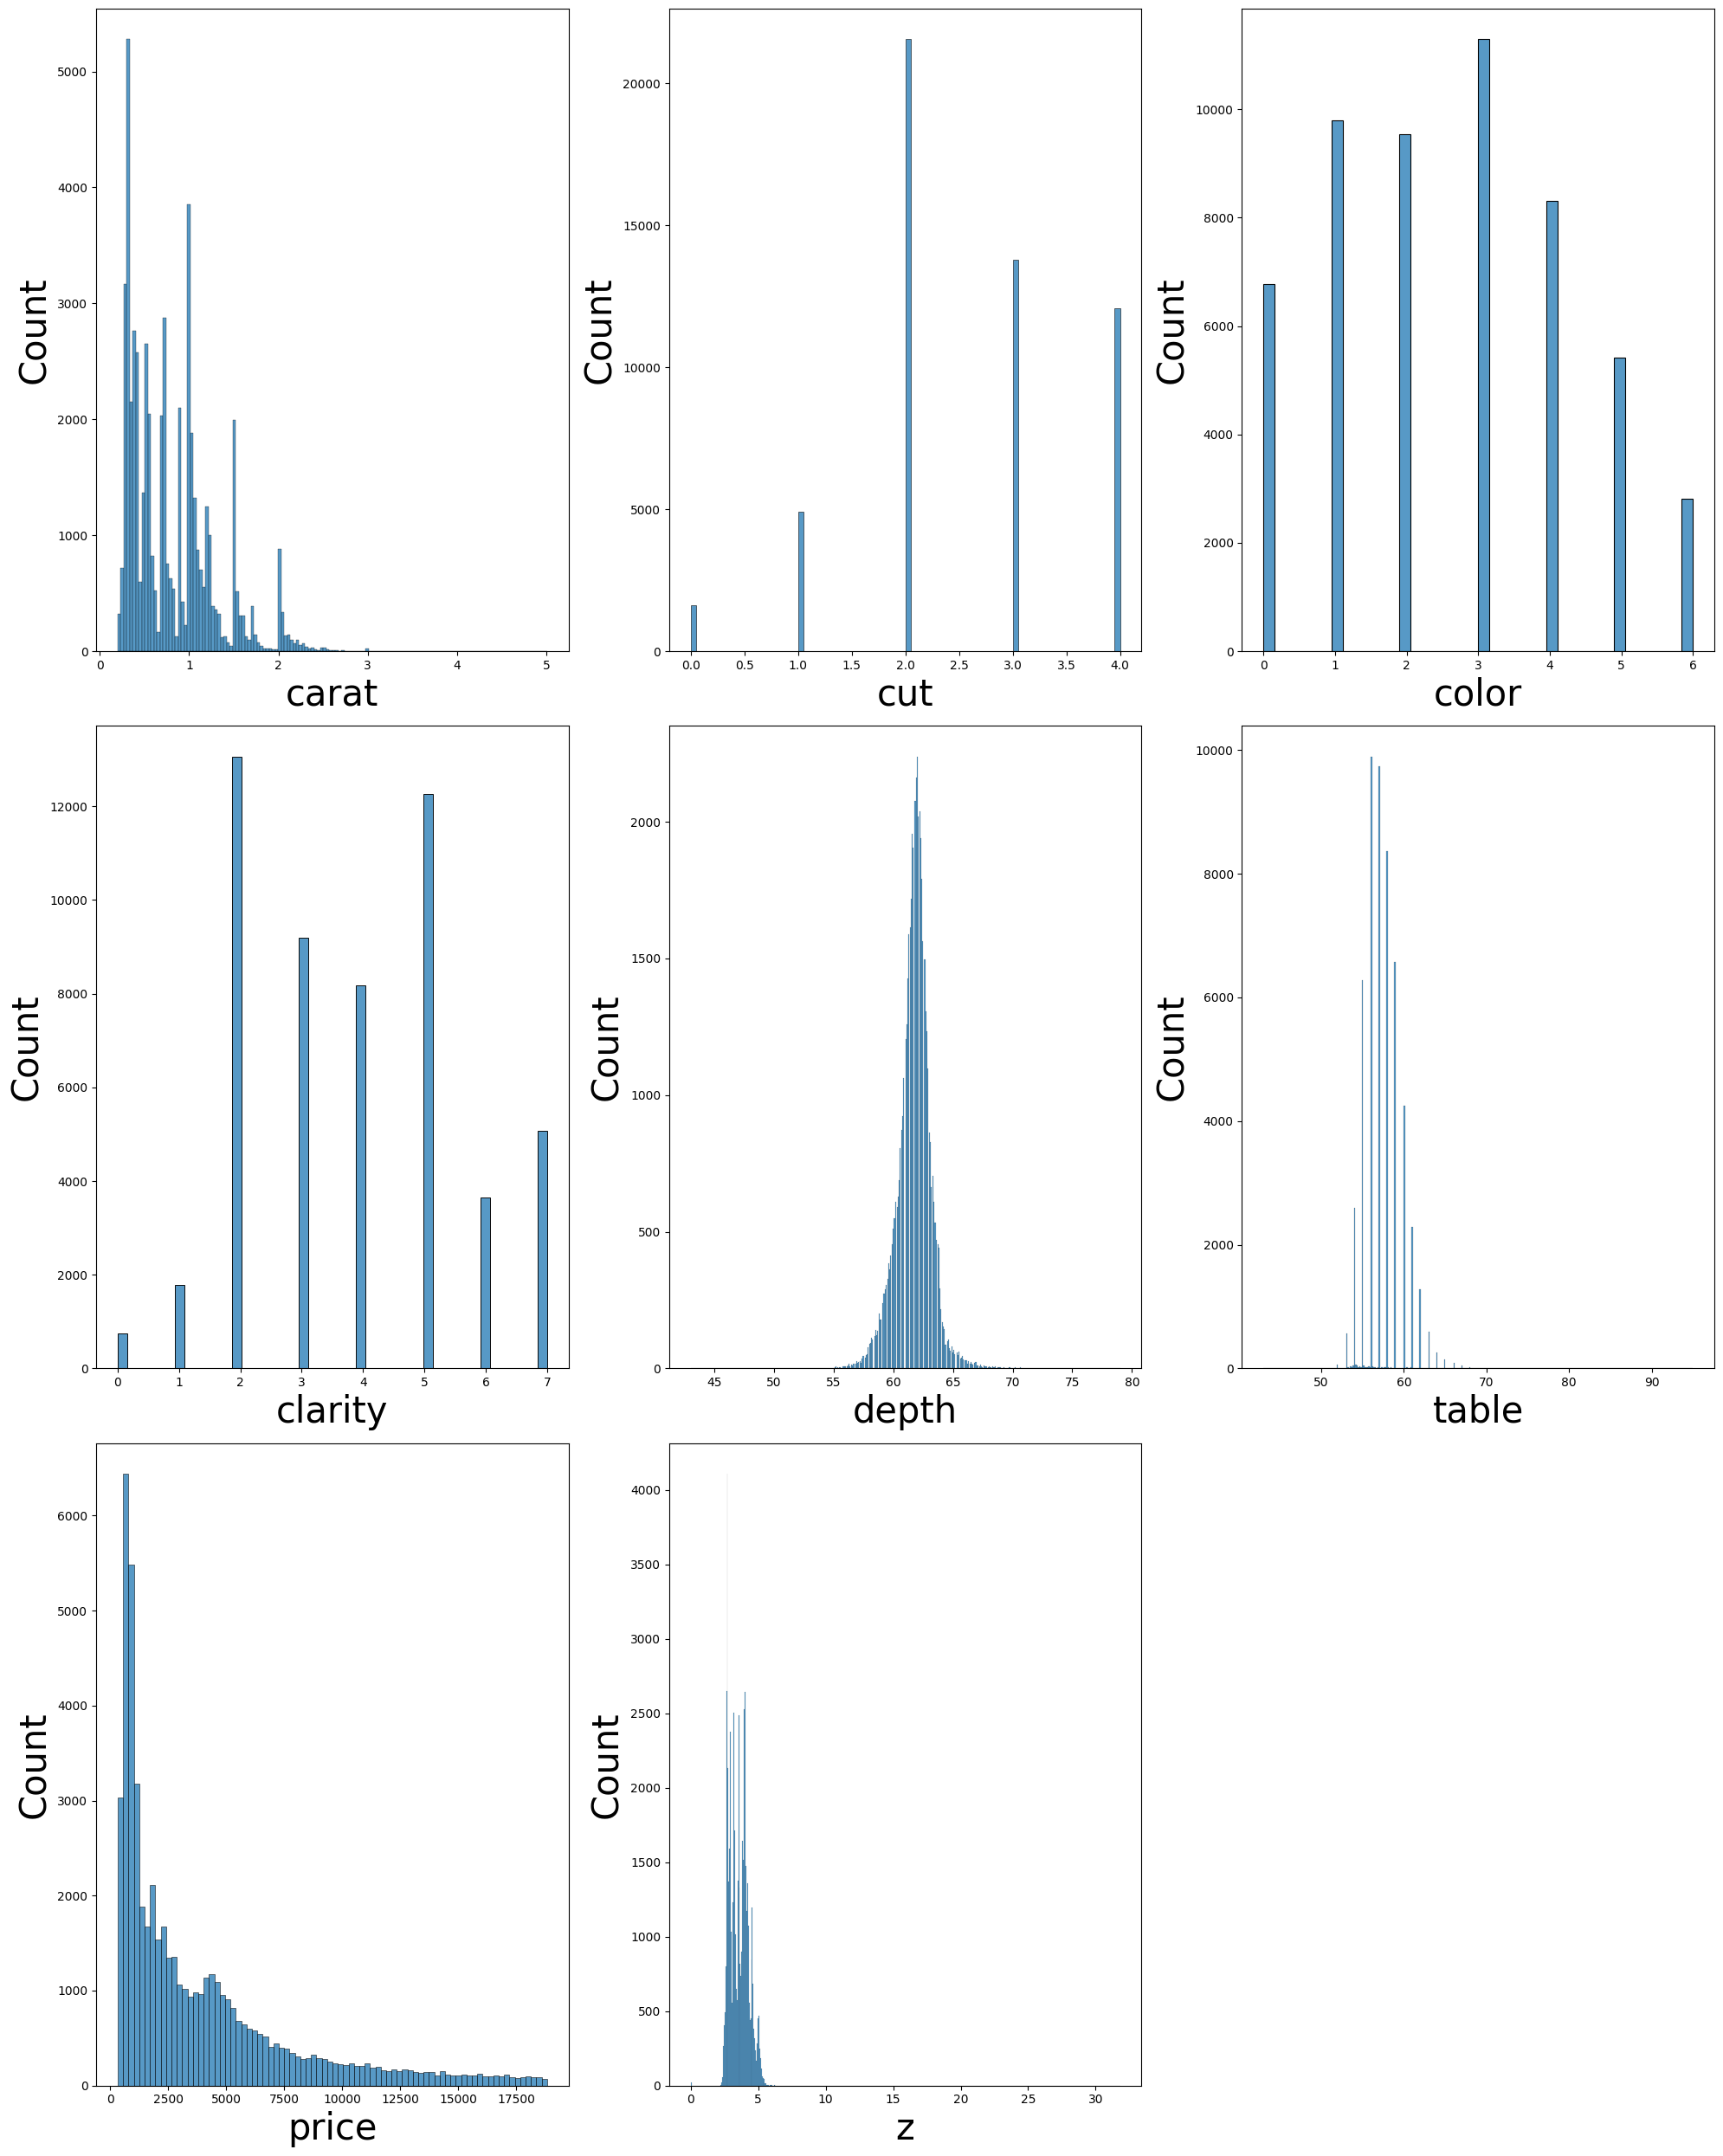

In [14]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.histplot(data[column])
        plt.xlabel(column,fontsize=30)
        plt.ylabel('Count',fontsize=30)
    plotnumber+=1
plt.tight_layout()

Nothing to be known

<Axes: xlabel='price', ylabel='carat'>

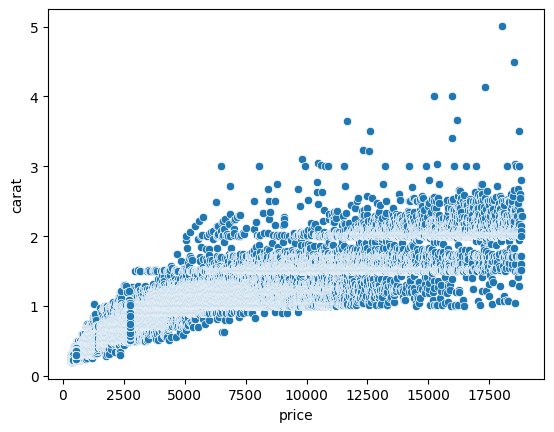

In [15]:
sns.scatterplot(x='price',y='carat',data=data)


#Price is increasing as the carat is increasing


<Axes: xlabel='carat'>

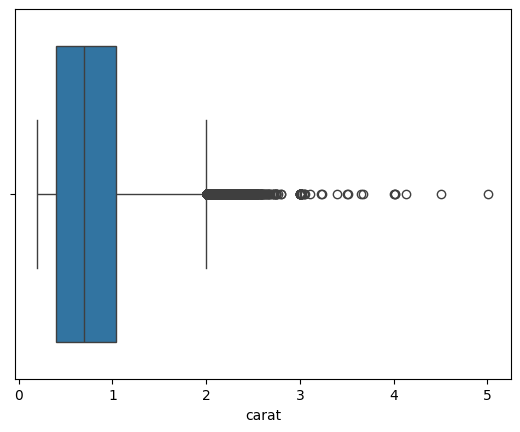

In [16]:
sns.boxplot(x='carat',data=data)

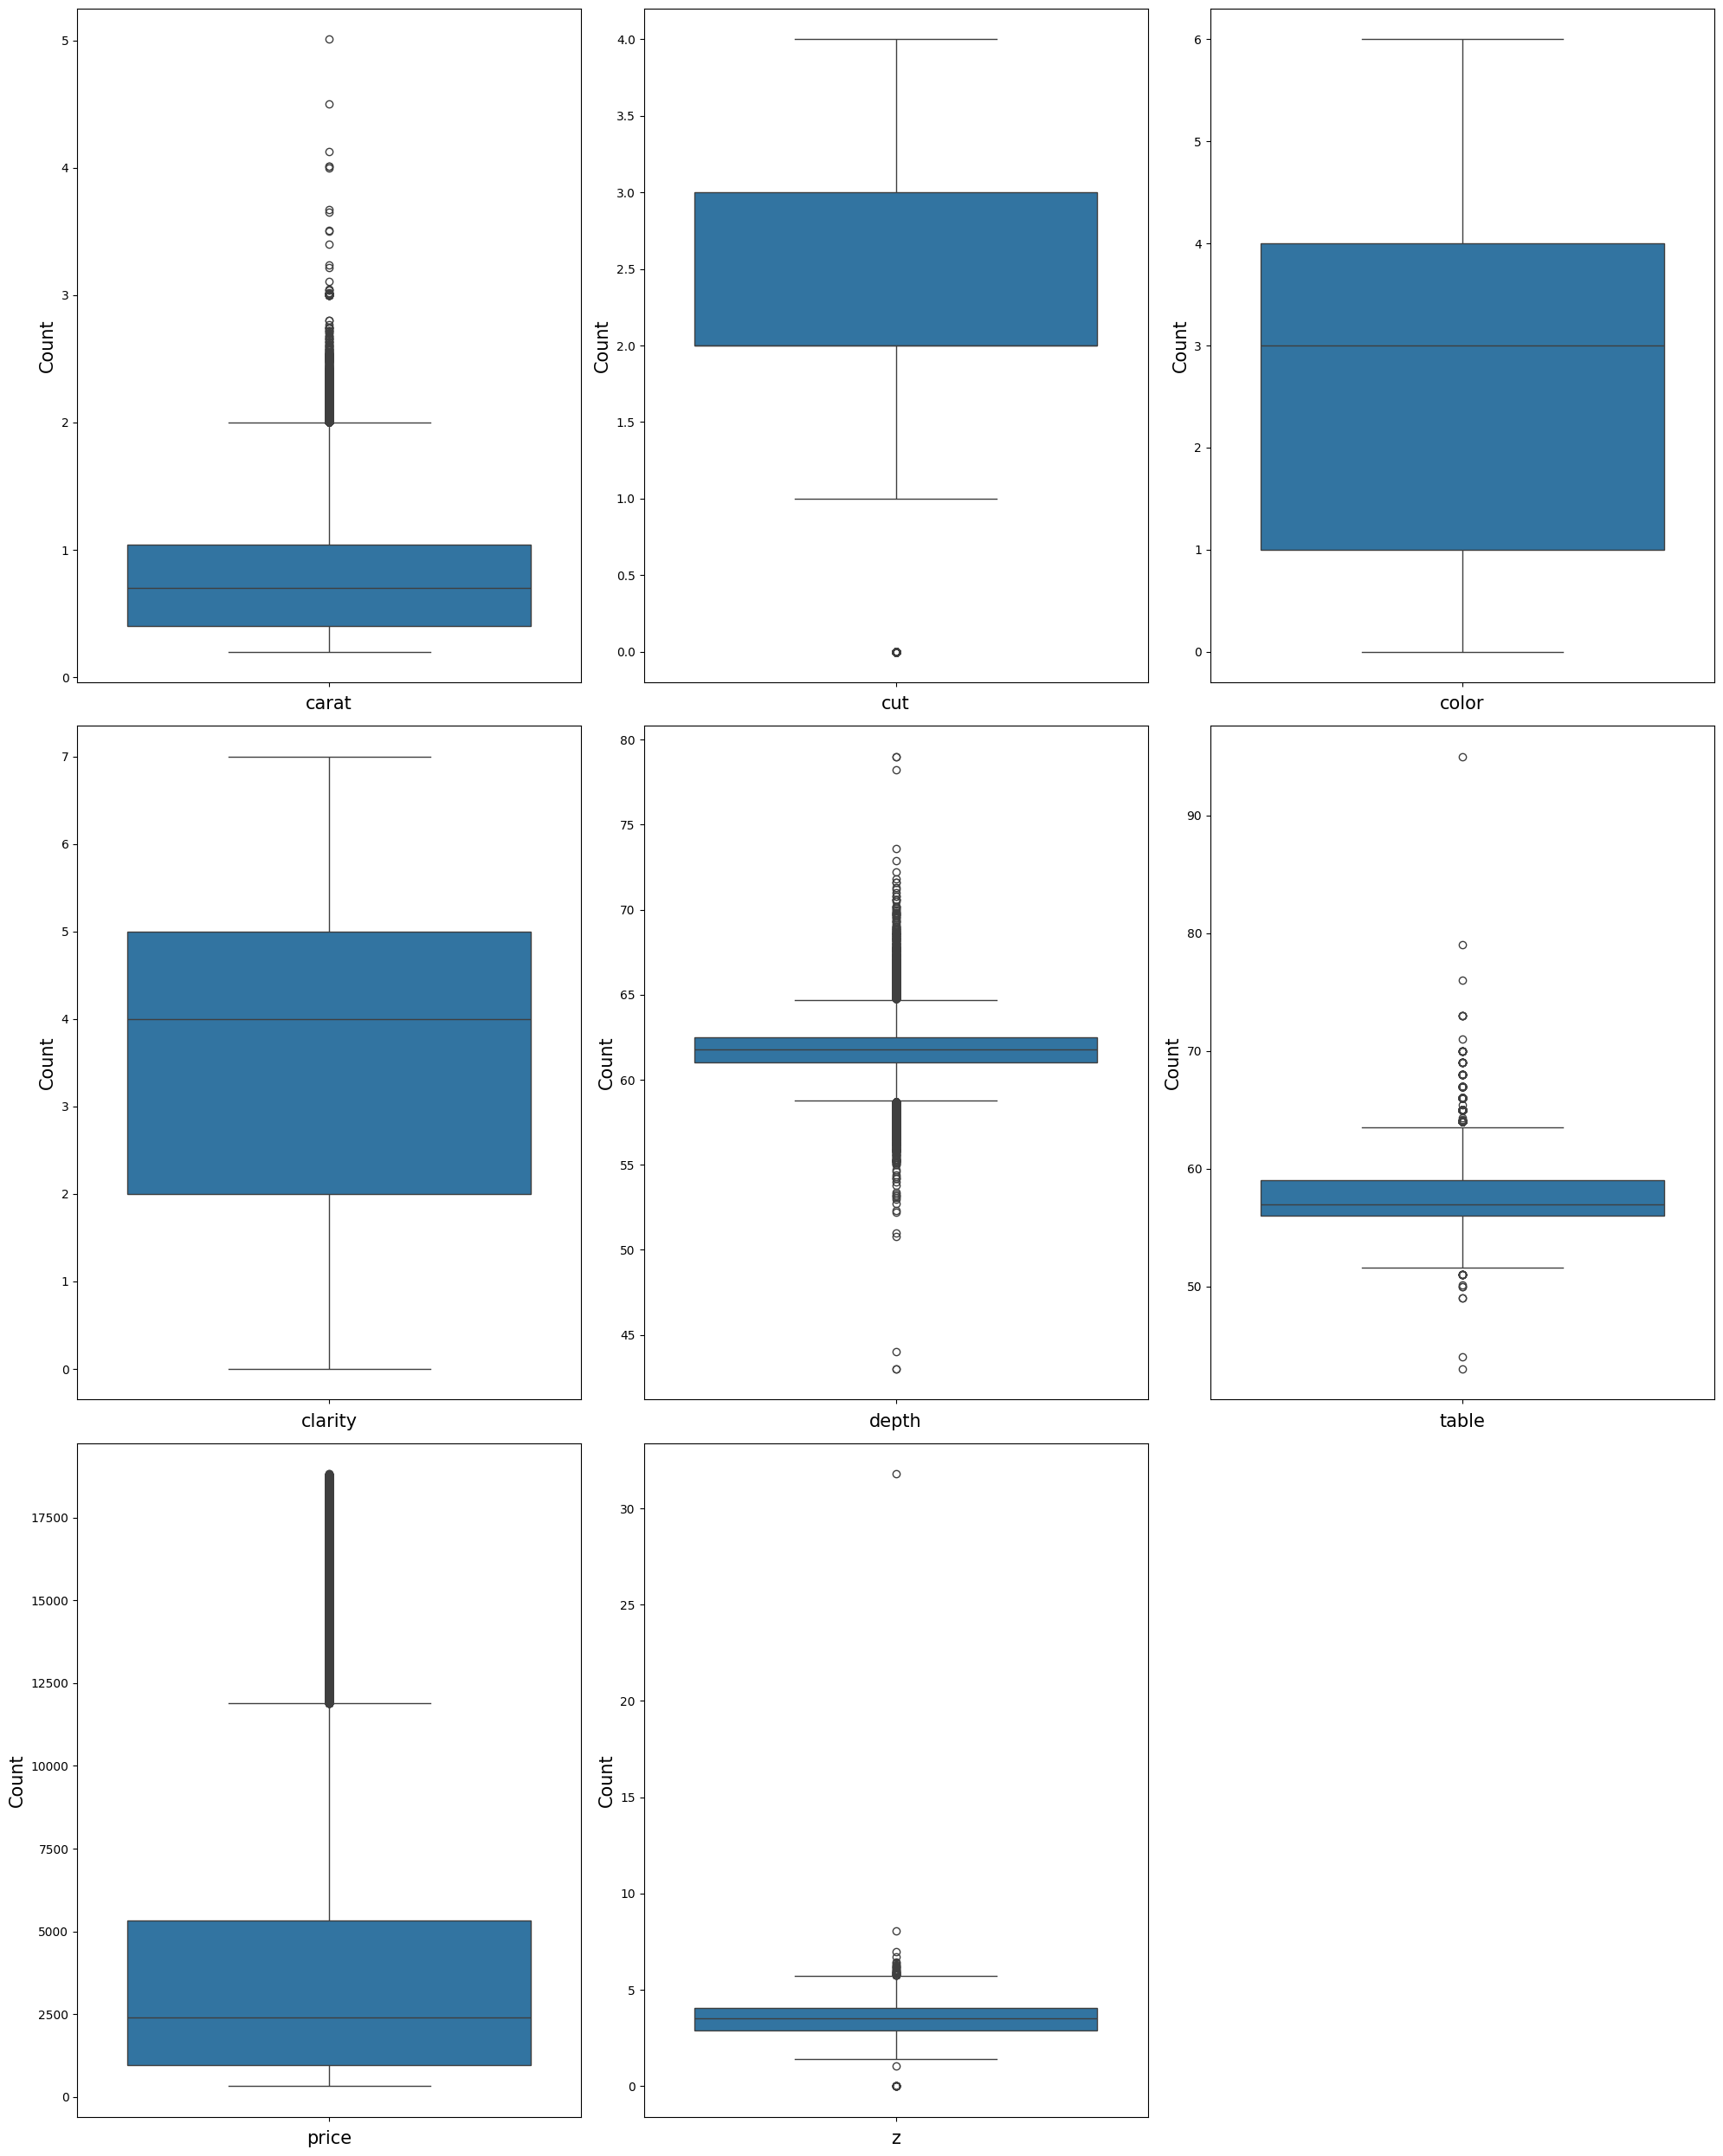

In [17]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(data[column])
        plt.xlabel(column,fontsize=15)
        plt.ylabel('Count',fontsize=15)
    plotnumber+=1
plt.tight_layout()

#Outliers are present in z,depth,table,cut

In [18]:

df = data[data['z'] > 0]

In [19]:
df

,carat,cut,color,clarity,depth,table,price,z
0,0.23,2,1,3,61.5,55.0,326,2.43
1,0.21,3,1,2,59.8,61.0,326,2.31
2,0.23,1,1,4,56.9,65.0,327,2.31
3,0.29,3,5,5,62.4,58.0,334,2.63
4,0.31,1,6,3,63.3,58.0,335,2.75
...,...,...,...,...,...,...,...,...
53935,0.72,2,0,2,60.8,57.0,2757,3.50
53936,0.72,1,0,2,63.1,55.0,2757,3.61
53937,0.70,4,0,2,62.8,60.0,2757,3.56
53938,0.86,3,4,3,61.0,58.0,2757,3.74


In [20]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Filter out the outliers
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply to each column
for col in ['carat', 'depth', 'table', 'z']:
    df = remove_outliers_iqr(df, col)


<Axes: >

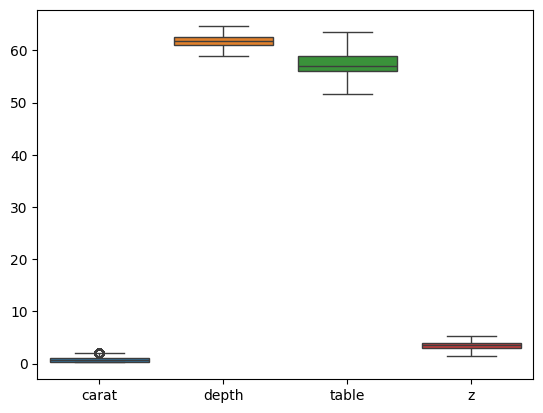

In [21]:
sns.boxplot(data=df[['carat', 'depth', 'table', 'z']])


Now there are no outliers present in the data

In [22]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
z          0
dtype: int64

In [23]:
df.head(2)

,carat,cut,color,clarity,depth,table,price,z
0,0.23,2,1,3,61.5,55.0,326,2.43
1,0.21,3,1,2,59.8,61.0,326,2.31


In [24]:
X = df.drop('price', axis=1)  # All features except 'price'
y = df['price']               # Only the target

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [28]:
lr.score(X_test,y_test)

0.878294453054419

In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [30]:
y_pred=lr.predict(X_test)

In [31]:
print(mean_absolute_error(y_test,y_pred))

752.9076932980254


In [32]:
print(mean_squared_error(y_test,y_pred))

1410629.0977386683


In [33]:
print(r2_score(y_test,y_pred))

0.878294453054419


In [34]:
kn=KNeighborsRegressor()
kn.fit(X_train,y_train)


KNeighborsRegressor()

In [35]:
kn.score(X_test,y_test)

0.8805255461442033

In [36]:
y_pred=kn.predict(X_test)

In [37]:
print(mean_absolute_error(y_test,y_pred))

640.1673006134969


In [38]:
print(mean_squared_error(y_test,y_pred))

1384769.5957586912


In [39]:
print(r2_score(y_test,y_pred))

0.8805255461442033


In [40]:
from sklearn.naive_bayes import GaussianNB

In [41]:
gnb=GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [47]:
c_pred = gnb.predict(X_test)

In [ ]:
print(accuracy_score(y_test, c_pred))
print(precision_score(y_test, c_pred, average='weighted'))
print(confusion_matrix(y_test, c_pred))
print(classification_report(y_test, c_pred))

0.008384458077709612
0.004601296318626208
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

         326       0.00      0.00      0.00         1
         336       0.00      0.00      0.00         1
         337       0.00      0.00      0.00         1
         338       0.00      0.00      0.00         1
         345       0.00      0.00      0.00         0
         351       0.00      0.00      0.00         0
         353       0.00      0.00      0.00         0
         361       0.00      0.00      0.00         1
         363       0.00      0.00      0.00         0
         365       0.00      0.00      0.00         0
         367       0.00      0.00      0.00         2
         368       0.07      0.50      0.12         2
         369       0.00      0.00      0.00         1
         370       0.00      0.00      0.00         1
         371       0.00    

: 